In [1]:
# =========================================
# LIBRERÍAS BÁSICAS
# =========================================

import numpy as np
import pandas as pd

# =========================================
# VISUALIZACIÓN
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# PREPROCESAMIENTO
# =========================================

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer

# ============================================================
# IMPORTS
# ============================================================

import joblib

In [2]:
# ¡OJO! el nuevo dataset tiene valores MÁS negativos de v3 no sirve el min de origen

class V3LogTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, feature_names):
        self.feature_names = feature_names
        
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X, columns=self.feature_names)
        self.v3_min_ = X_df['V3'].min()
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names).copy()
        
        X_df['V3_shift'] = X_df['V3'] - self.v3_min_ + 1
        
        # Evita valores <= -1 antes de log1p (nuevo)
        X_df['V3_shift'] = X_df['V3_shift'].clip(lower=0)
        
        X_df['V3_log'] = np.log1p(X_df['V3_shift'])
        
        X_df = X_df.drop(columns=['V3', 'V3_shift'])
        
        return X_df

In [3]:
# cargo el modelo / pipeline:
pipe_modelo = joblib.load("gbr_final_pipeline.pkl")

In [4]:
df_entradas = pd.read_excel('../test_competicion_entradas.xlsx')
df_entradas.head(10)

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9
0,NaN,4.887601,1.732051,0.036594,0.654492,2.706,1.313,3.0,1.0,0.005405
1,NaN,4.010166,1.000000,5.240823,1.267922,2.472,0.638,NaN,0.0,0.204247
2,NaN,4.873180,2.000000,0.791453,-0.820122,3.178,1.263,2.0,1.0,0.851594
3,NaN,0.000000,NaN,2.537717,-1.410141,1.334,1.212,0.0,0.0,0.844862
4,NaN,NaN,1.000000,10.546683,-1.232321,1.960,1.020,0.0,0.0,0.166053
5,NaN,0.000000,0.000000,31.824876,0.304636,NaN,0.711,0.0,0.0,0.697716
6,NaN,4.731750,0.000000,35.126422,-0.897046,2.661,1.243,2.0,0.0,0.496896
7,NaN,0.000000,NaN,163.846914,-0.293847,2.676,0.577,0.0,0.0,0.125566
8,NaN,4.201613,NaN,46.113794,0.229701,2.758,0.518,NaN,0.0,0.111209
9,NaN,4.379874,1.000000,20.978904,-0.818404,NaN,1.022,NaN,NaN,0.317983


In [5]:
df_entradas.describe().T

,count,mean,std,min,25%,50%,75%,max
V0,28.0,43.586429,37.073166,0.000000,16.835000,39.950000,60.987500,122.220000
V1,99.0,2.909752,1.821780,0.000000,0.708412,3.738336,4.216612,5.200517
V2,91.0,0.549675,0.662529,0.000000,0.000000,0.000000,1.000000,2.000000
V3,96.0,29.942648,44.759376,-7.529536,1.892619,13.558188,35.443897,234.428582
V4,110.0,0.094229,0.897718,-2.407344,-0.530846,0.159071,0.731993,2.479389
V5,91.0,2.363022,0.640846,1.000000,1.942000,2.397000,2.737500,3.866000
V6,98.0,1.094214,0.442857,0.375000,0.728000,1.058000,1.366250,2.353000
V7,88.0,0.772727,1.131851,0.000000,0.000000,0.000000,1.000000,5.000000
V8,96.0,0.260417,0.547622,0.000000,0.000000,0.000000,0.000000,2.000000
V9,110.0,0.519281,0.305160,0.005405,0.249470,0.563134,0.799458,0.989432


In [6]:
df_entradas.isnull().sum()

V0    82
V1    11
V2    19
V3    14
V4     0
V5    19
V6    12
V7    22
V8    14
V9     0
dtype: int64

In [7]:
df_entradas.shape

(110, 10)

## Lectura 

Tenemos un problema con esos missings de V0 (fallo de un sensor) porque es una variable explicativa top4 y sin ella (borrar) nos cargamos el modelo (aumenta mucho MSE)

Dos formas de pensar:

1. Conservadora -> tal como me viene 'test_competicion_entradas.xlsx' le aplico el pipeline guardado
2. Esperimental -> aprovecho el historico que tenemos en el dataset de train para aplicar KNNImputer

# CONSERVADORA

In [8]:
df_test = pd.read_excel('../test_competicion_entradas.xlsx')


In [9]:
pred_conservadora = pipe_modelo.predict(df_test)

In [10]:
deseada_conservadora = pd.DataFrame({'deseada': pred_conservadora})
deseada_conservadora

,deseada
0,4.214849
1,4.485559
2,3.854002
3,3.494798
4,4.632594
...,...
105,4.970470
106,4.628868
107,4.658003
108,1.339156


# EXPERIMENTAL

In [11]:
df_train = pd.read_excel('../train_competicion.xlsx')

X_train_full = df_train.drop(columns='deseada')

Concateno ambos datasets con el objetivo de imputar KNN k=5, así hay más datos, especialmente para V0.

In [12]:
X_concat = pd.concat([X_train_full, df_test],  axis=0)

In [13]:
imputer = KNNImputer(n_neighbors=5)

X_concat_imputed = pd.DataFrame(
                                imputer.fit_transform(X_concat),
                                columns=X_concat.columns
                            )

Ahora separo desde el punto que he concatenado. Objetivo: una vez imputados los nulos con más datos (supuestamente imputará mejor), quito el "train" para quedarme solo el "test" a quien le voy a aplicar el predict.

In [14]:
X_test_imputed = X_concat_imputed.iloc[len(X_train_full):]

In [15]:
pred_experimental = pipe_modelo.predict(X_test_imputed)

In [16]:
deseada_experimental = pd.DataFrame({'deseada': pred_experimental})
deseada_experimental

,deseada
0,4.214849
1,4.485559
2,3.854002
3,3.494798
4,4.632594
...,...
105,5.251600
106,4.628868
107,4.658003
108,1.339156


In [17]:
## Comparativa

In [18]:
deseada_conservadora.describe()

,deseada
count,110.000000
mean,4.477733
std,1.182128
min,1.339156
25%,3.814245
50%,4.439977
75%,5.118142
max,7.038542


In [19]:
deseada_experimental.describe()

,deseada
count,110.000000
mean,4.450652
std,1.136576
min,1.339156
25%,3.814245
50%,4.445940
75%,5.109644
max,6.666580


In [20]:
diff = deseada_conservadora - deseada_experimental
diff.describe()

,deseada
count,110.000000
mean,0.027081
std,0.258044
min,-0.870880
25%,0.000000
50%,0.000000
75%,0.000000
max,1.445024


In [21]:
print((abs(diff) > 1).sum())
print((abs(diff) > 2).sum())

deseada    2
dtype: int64
deseada    0
dtype: int64


In [22]:
diff_abs = np.abs(np.array(deseada_experimental) - np.array(deseada_conservadora))

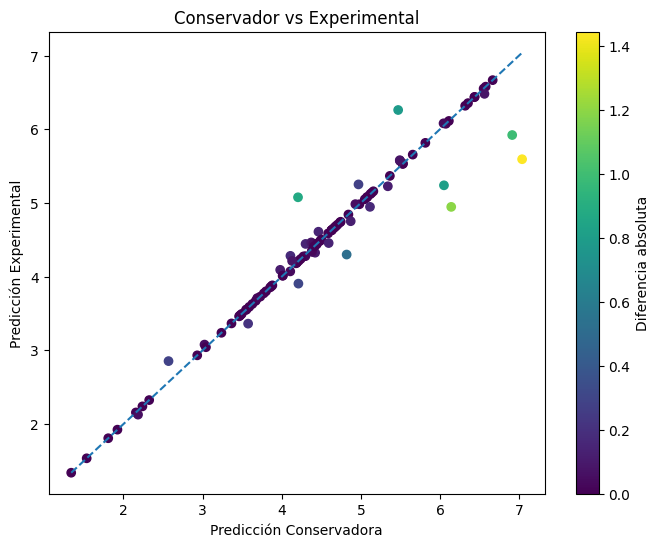

In [23]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
                        deseada_conservadora,
                        deseada_experimental,
                        c=diff_abs,
                        cmap='viridis'
                    )

plt.colorbar(scatter, label='Diferencia absoluta')

plt.xlabel('Predicción Conservadora')
plt.ylabel('Predicción Experimental')

plt.title('Conservador vs Experimental')

plt.plot(
    [deseada_conservadora.min(), deseada_conservadora.max()],
    [deseada_conservadora.min(), deseada_conservadora.max()],
    linestyle='--'
)

plt.show()

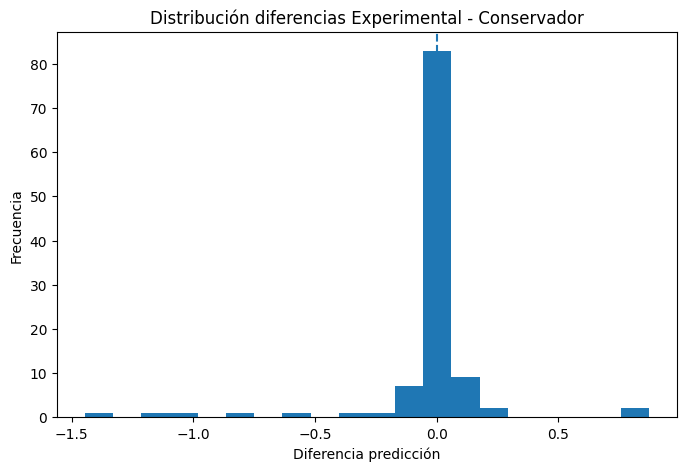

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
            deseada_experimental - deseada_conservadora,
            bins=20
        )

plt.axvline(0, linestyle='--')

plt.title('Distribución diferencias Experimental - Conservador')

plt.xlabel('Diferencia predicción')

plt.ylabel('Frecuencia')

plt.show()

In [25]:
# Esportaciones (formato xls)

deseada_conservadora.to_excel("prediccionesGBR_SGalvez_conservadora.xlsx",index=False)
deseada_experimental.to_excel("prediccionesGBR_SGalvez_experimental.xlsx",index=False)